# Práctica 1 — Modelo de pérdidas del ramo de Automóviles

## Equipo 02

**Producto:** Seguro de Automóviles Particulares — Cobertura Amplia

### Objetivo

El objetivo de esta práctica es analizar la cartera asignada al ramo de automóviles particulares y construir un modelo agregado de pérdidas. Para ello se modelarán por separado la severidad y la frecuencia de los siniestros, se seleccionarán distribuciones adecuadas con base en criterios estadísticos y actuariales, y finalmente se simulará la pérdida agregada \(S\). También se evaluará el efecto de las condiciones de la póliza sobre las pérdidas asumidas por la aseguradora.

### Preguntas de introducción

**¿Por qué nos interesó este ramo?**

Elegimos el ramo de automóviles particulares porque permite aplicar de manera clara los conceptos de frecuencia y severidad a un riesgo cotidiano y de gran relevancia para el mercado asegurador. Además, los siniestros de automóviles pueden presentar montos muy distintos entre sí, por lo que resulta interesante analizar tanto el comportamiento típico de las pérdidas como su cola y el impacto de siniestros de mayor cuantía.

**¿Qué coberturas vamos a trabajar en nuestro producto?**

Nuestro producto corresponde a un Seguro de Automóviles Particulares con Cobertura Amplia. Consideramos principalmente daños materiales, robo total, responsabilidad civil por daños a terceros y gastos médicos a ocupantes. Para la modelación de esta práctica se utilizarán las pérdidas y condiciones de póliza disponibles en la cartera asignada, incluyendo el efecto del deducible y de la suma asegurada.

## 1. Carga y revisión de los datos

En esta sección se carga la cartera asignada al Equipo 02 y se realiza una primera revisión de su estructura, dimensiones, variables y tipos de datos. Esta exploración permitirá identificar las variables que se utilizarán posteriormente para modelar la severidad, la frecuencia y las condiciones de la póliza.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Ruta de la cartera asignada al Equipo 02
ruta_cartera = Path("../inputs/cartera.parquet")

# Cargar la cartera
df = pd.read_parquet(ruta_cartera)

print(f"Dimensiones de la cartera: {df.shape[0]} filas × {df.shape[1]} columnas")
display(df.head())

Dimensiones de la cartera: 30000 filas × 14 columnas


,id_poliza,exposicion,edad_conductor,sexo,antiguedad_vehiculo,tipo_vehiculo,uso,zona,suma_asegurada,deducible,coaseguro,num_siniestros,monto_total_siniestros,monto_promedio_siniestro
0,P000001,0.805,31,F,14,suv,particular,sureste,355714.0,17786.0,0.0,1,5903.70,5903.70
1,P000002,0.822,24,F,13,suv,particular,norte,213609.0,10680.0,0.0,3,216045.21,72015.07
2,P000003,0.872,74,M,6,compacto,particular,norte,327262.0,16363.0,0.0,1,58285.15,58285.15
3,P000004,0.928,26,M,8,lujo,particular,sur,444502.0,22225.0,0.0,1,377290.47,377290.47
4,P000005,0.674,49,M,9,compacto,particular,norte,487112.0,24356.0,0.0,0,0.00,NaN


In [2]:
# Revisión de estructura y calidad de la cartera

print("COLUMNAS DE LA CARTERA")
print(df.columns.tolist())

print("\nTIPOS DE DATOS")
print(df.dtypes)

print("\nVALORES FALTANTES")
faltantes = pd.DataFrame({
    "faltantes": df.isna().sum(),
    "porcentaje": 100 * df.isna().mean()
})
display(faltantes)

print("\nRESUMEN DE VARIABLES ACTUARIALES")
variables_actuariales = [
    "exposicion",
    "suma_asegurada",
    "deducible",
    "coaseguro",
    "num_siniestros",
    "monto_total_siniestros",
    "monto_promedio_siniestro"
]

display(df[variables_actuariales].describe().T)

COLUMNAS DE LA CARTERA
['id_poliza', 'exposicion', 'edad_conductor', 'sexo', 'antiguedad_vehiculo', 'tipo_vehiculo', 'uso', 'zona', 'suma_asegurada', 'deducible', 'coaseguro', 'num_siniestros', 'monto_total_siniestros', 'monto_promedio_siniestro']

TIPOS DE DATOS
id_poliza                    object
exposicion                  float64
edad_conductor                int64
sexo                         object
antiguedad_vehiculo           int64
tipo_vehiculo                object
uso                          object
zona                         object
suma_asegurada              float64
deducible                   float64
coaseguro                   float64
num_siniestros                int64
monto_total_siniestros      float64
monto_promedio_siniestro    float64
dtype: object

VALORES FALTANTES


,faltantes,porcentaje
id_poliza,0,0.000000
exposicion,0,0.000000
edad_conductor,0,0.000000
sexo,0,0.000000
antiguedad_vehiculo,0,0.000000
tipo_vehiculo,0,0.000000
uso,0,0.000000
zona,0,0.000000
suma_asegurada,0,0.000000
deducible,0,0.000000



RESUMEN DE VARIABLES ACTUARIALES


,count,mean,std,min,25%,50%,75%,max
exposicion,30000.0,0.800188,0.120387,0.217,0.7280,0.821,0.893,0.999
suma_asegurada,30000.0,358317.316433,138385.329243,120005.000,238683.0000,357382.500,477050.000,599985.000
deducible,30000.0,17915.864633,6919.265332,6000.000,11934.5000,17869.000,23852.250,29999.000
coaseguro,30000.0,0.000000,0.000000,0.000,0.0000,0.000,0.000,0.000
num_siniestros,30000.0,0.295067,0.606312,0.000,0.0000,0.000,0.000,6.000
monto_total_siniestros,30000.0,15330.692487,49957.480284,0.000,0.0000,0.000,0.000,1840512.100
monto_promedio_siniestro,6968.0,51883.303357,65043.890806,544.080,17826.5425,32994.070,61995.850,1322156.920


In [3]:
# Indicadores generales de la cartera

exposicion_total = df["exposicion"].sum()
siniestros_totales = df["num_siniestros"].sum()
polizas_con_siniestro = (df["num_siniestros"] > 0).sum()
prop_ceros = (df["num_siniestros"] == 0).mean()

print(f"Exposición total: {exposicion_total:,.2f} años-póliza")
print(f"Número total de siniestros: {siniestros_totales:,}")
print(f"Pólizas con al menos un siniestro: {polizas_con_siniestro:,}")
print(f"Proporción de pólizas sin siniestro: {100*prop_ceros:.2f}%")
print(f"Frecuencia empírica: {siniestros_totales/exposicion_total:.4f} siniestros por año-póliza")

Exposición total: 24,005.64 años-póliza
Número total de siniestros: 8,852
Pólizas con al menos un siniestro: 6,968
Proporción de pólizas sin siniestro: 76.77%
Frecuencia empírica: 0.3687 siniestros por año-póliza


### Conclusión de la revisión inicial

La cartera del Equipo 02 contiene 30,000 pólizas y una exposición total de 24,005.64 años-póliza. Durante el periodo analizado se registraron 8,852 siniestros, distribuidos entre 6,968 pólizas con al menos un siniestro. La frecuencia empírica de la cartera es de 0.3687 siniestros por año-póliza.

También se observa que el 76.77% de las pólizas no presentó siniestros. Esta elevada proporción de ceros será considerada posteriormente al evaluar el ajuste de las distribuciones de frecuencia, particularmente al comparar Poisson y Binomial Negativa y al diagnosticar posibles fenómenos de sobredispersión o exceso de ceros.

In [4]:
# Revisión de las variables relacionadas con severidad

sev_revision = df.loc[
    df["num_siniestros"] > 0,
    ["num_siniestros", "monto_total_siniestros", "monto_promedio_siniestro"]
].copy()

sev_revision["promedio_calculado"] = (
    sev_revision["monto_total_siniestros"] /
    sev_revision["num_siniestros"]
)

print(f"Pólizas con siniestros: {len(sev_revision):,}")

display(sev_revision.head(10))

diferencia = (
    sev_revision["monto_promedio_siniestro"]
    - sev_revision["promedio_calculado"]
).abs()

print(f"Diferencia máxima: {diferencia.max():.6f}")
print(f"Diferencia media: {diferencia.mean():.6f}")

Pólizas con siniestros: 6,968


,num_siniestros,monto_total_siniestros,monto_promedio_siniestro,promedio_calculado
0,1,5903.70,5903.70,5903.70
1,3,216045.21,72015.07,72015.07
2,1,58285.15,58285.15,58285.15
3,1,377290.47,377290.47,377290.47
7,1,12090.28,12090.28,12090.28
10,1,8756.06,8756.06,8756.06
15,1,60923.09,60923.09,60923.09
16,1,66048.35,66048.35,66048.35
21,1,12692.59,12692.59,12692.59
28,1,28646.29,28646.29,28646.29


Diferencia máxima: 0.005000
Diferencia media: 0.000510


## 2. Exploración de la severidad

La cartera se encuentra agregada a nivel póliza. Para las pólizas con siniestros, la variable `monto_promedio_siniestro` coincide, salvo diferencias mínimas de redondeo, con el cociente entre el monto total de siniestros y el número de siniestros.

Por ello, para construir una muestra a nivel siniestro se utiliza el monto promedio de cada póliza tantas veces como siniestros haya registrado. De esta forma cada observación de la muestra representa un siniestro y se conserva el número total de eventos de la cartera.

In [5]:
# Construcción de la muestra de severidades por siniestro

datos_con_siniestro = df.loc[
    df["num_siniestros"] > 0,
    ["num_siniestros", "monto_promedio_siniestro"]
].copy()

x = np.repeat(
    datos_con_siniestro["monto_promedio_siniestro"].to_numpy(),
    datos_con_siniestro["num_siniestros"].astype(int).to_numpy()
)

print(f"Número de severidades construidas: {len(x):,}")
print(f"Número total de siniestros de la cartera: {df['num_siniestros'].sum():,}")
print(f"Todos los montos son positivos: {np.all(x > 0)}")

pd.Series(x, name="severidad").describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)

Número de severidades construidas: 8,852
Número total de siniestros de la cartera: 8,852
Todos los montos son positivos: True


count    8.852000e+03
mean     5.195671e+04
std      6.201350e+04
min      5.440800e+02
50%      3.452647e+04
75%      6.258436e+04
90%      1.086136e+05
95%      1.512814e+05
99%      2.876131e+05
max      1.322157e+06
Name: severidad, dtype: float64

### Construcción y comportamiento inicial de la severidad

La cartera registra un total de 8,852 siniestros. Debido a que la información se encuentra agregada a nivel póliza, la severidad individual se aproxima utilizando el monto promedio de siniestro de cada póliza repetido de acuerdo con su número de siniestros. Con este procedimiento se obtienen 8,852 observaciones positivas, coincidiendo exactamente con el número total de eventos de la cartera.

Esta reconstrucción conserva el número de siniestros y el monto agregado de las pólizas, aunque puede reducir parte de la variabilidad existente entre siniestros individuales de una misma póliza, por lo que esta limitación se tendrá presente al interpretar los ajustes.

La severidad presenta una media aproximada de $51,957 y una mediana de $34,533. Además, el percentil 99 se encuentra alrededor de $287,613 y el máximo observado supera $1.32 millones. La diferencia entre la media y la mediana, junto con la presencia de observaciones de gran magnitud, sugiere una distribución asimétrica positiva con una cola derecha relevante.

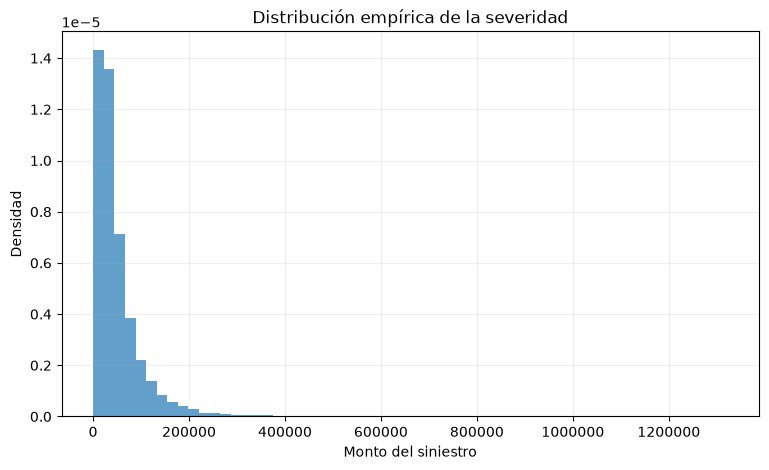

In [6]:
# Histograma de la severidad en escala original

plt.figure(figsize=(9, 5))
plt.hist(x, bins=60, density=True, alpha=0.7)

plt.xlabel("Monto del siniestro")
plt.ylabel("Densidad")
plt.title("Distribución empírica de la severidad")
plt.ticklabel_format(style="plain", axis="x")
plt.grid(alpha=0.2)

plt.show()

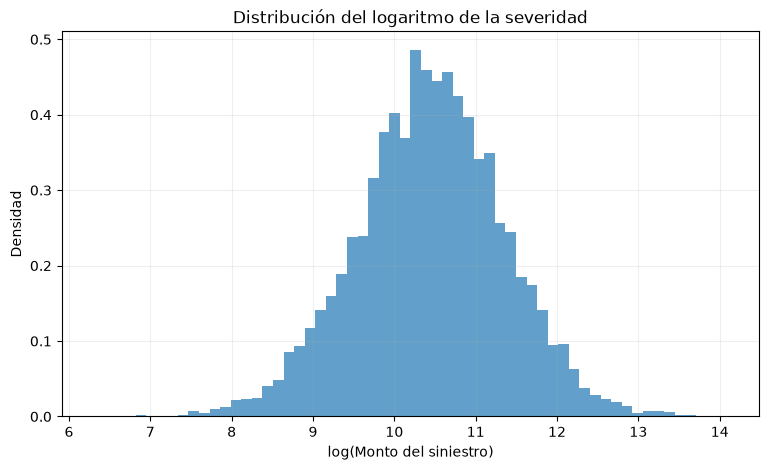

In [7]:
# Histograma del logaritmo de la severidad

log_x = np.log(x)

plt.figure(figsize=(9, 5))
plt.hist(log_x, bins=60, density=True, alpha=0.7)

plt.xlabel("log(Monto del siniestro)")
plt.ylabel("Densidad")
plt.title("Distribución del logaritmo de la severidad")
plt.grid(alpha=0.2)

plt.show()

In [8]:
# Cuantiles empíricos relevantes para estudiar la cola

cuantiles = pd.Series(
    np.quantile(x, [0.50, 0.75, 0.90, 0.95, 0.975, 0.99, 0.995]),
    index=["50%", "75%", "90%", "95%", "97.5%", "99%", "99.5%"],
    name="Severidad"
)

display(cuantiles.to_frame().style.format("${:,.2f}"))

,Severidad
50%,"$34,526.47"
75%,"$62,584.36"
90%,"$108,613.58"
95%,"$151,281.39"
97.5%,"$197,268.68"
99%,"$287,613.08"
99.5%,"$390,023.88"


### Exploración gráfica de la severidad

El histograma de la severidad en escala original muestra una marcada asimetría positiva, con una elevada concentración de observaciones en montos relativamente pequeños y una cola derecha prolongada asociada a siniestros de mayor cuantía.

Al analizar el logaritmo de la severidad, la distribución adquiere una forma mucho más simétrica y aproximadamente acampanada. Este comportamiento proporciona evidencia gráfica a favor de considerar a la distribución Lognormal como una candidata relevante, aunque su selección definitiva se realizará comparándola con otras distribuciones mediante criterios de ajuste y comportamiento de la cola.

Los cuantiles empíricos confirman la importancia de las pérdidas extremas. Mientras que la mediana es cercana a $34.5 mil, el percentil 95 supera los $151 mil, el percentil 99 se aproxima a $288 mil y el percentil 99.5 alcanza aproximadamente $390 mil. Por ello, además del ajuste global, será necesario evaluar explícitamente la capacidad de cada distribución para representar la cola de la severidad.

In [9]:
# Ajuste de distribuciones candidatas para la severidad
# Se fija loc = 0 porque los montos de siniestro son positivos.

distribuciones = {
    "Lognormal": stats.lognorm,
    "Gamma": stats.gamma,
    "Weibull": stats.weibull_min,
    "Pareto": stats.pareto
}

ajustes_severidad = {}
resultados = []

for nombre, distribucion in distribuciones.items():

    # Ajuste por máxima verosimilitud
    params = distribucion.fit(x, floc=0)

    # Log-verosimilitud
    loglik = np.sum(distribucion.logpdf(x, *params))

    # Con loc fijado en cero quedan 2 parámetros estimados:
    # forma y escala
    k = 2

    # Criterios de información
    aic = 2 * k - 2 * loglik
    bic = k * np.log(len(x)) - 2 * loglik

    ajustes_severidad[nombre] = {
        "distribucion": distribucion,
        "params": params
    }

    resultados.append({
        "Distribución": nombre,
        "Log-verosimilitud": loglik,
        "AIC": aic,
        "BIC": bic,
        "Parámetros": tuple(np.round(params, 6))
    })

tabla_ajustes = pd.DataFrame(resultados).sort_values("AIC").reset_index(drop=True)

display(
    tabla_ajustes.style.format({
        "Log-verosimilitud": "{:,.2f}",
        "AIC": "{:,.2f}",
        "BIC": "{:,.2f}"
    })
)

,Distribución,Log-verosimilitud,AIC,BIC,Parámetros
0,Lognormal,"-104,183.80","208,371.61","208,385.78","(np.float64(0.913966), np.float64(0.0), np.float64(34219.281396))"
1,Gamma,"-104,753.97","209,511.94","209,526.12","(np.float64(1.339423), np.float64(0.0), np.float64(38790.360765))"
2,Weibull,"-104,909.18","209,822.36","209,836.53","(np.float64(1.086665), np.float64(0.0), np.float64(53915.791286))"
3,Pareto,"-113,850.80","227,705.59","227,719.77","(np.float64(0.241461), np.float64(0.0), np.float64(544.08))"


### Ajuste de distribuciones candidatas

Se ajustaron las distribuciones Lognormal, Gamma, Weibull y Pareto mediante máxima verosimilitud, fijando el parámetro de localización en cero debido a que la severidad toma únicamente valores positivos.

De acuerdo con los criterios de información, la distribución Lognormal presenta el mejor ajuste global entre las candidatas analizadas. Su log-verosimilitud es la mayor y registra los menores valores tanto de AIC como de BIC. La diferencia respecto a las demás distribuciones es considerable, particularmente frente a Pareto.

Este resultado también es consistente con la exploración gráfica previa, donde el logaritmo de la severidad mostró una forma aproximadamente simétrica. Sin embargo, la elección definitiva no se basará únicamente en AIC y BIC, pues para un seguro de automóviles es especialmente importante representar adecuadamente la cola de la distribución. Por ello, a continuación se compararán cuantiles empíricos y teóricos de niveles elevados.

In [10]:
# Comparación de cuantiles empíricos y teóricos en la cola

niveles = np.array([0.90, 0.95, 0.975, 0.99, 0.995])

cuantiles_empiricos = np.quantile(x, niveles)

comparacion_cola = pd.DataFrame({
    "Nivel": niveles,
    "Empírico": cuantiles_empiricos
})

for nombre, ajuste in ajustes_severidad.items():
    dist = ajuste["distribucion"]
    params = ajuste["params"]

    comparacion_cola[nombre] = dist.ppf(niveles, *params)

display(
    comparacion_cola.style.format({
        "Nivel": "{:.1%}",
        "Empírico": "${:,.2f}",
        "Lognormal": "${:,.2f}",
        "Gamma": "${:,.2f}",
        "Weibull": "${:,.2f}",
        "Pareto": "${:,.2f}"
    })
)

,Nivel,Empírico,Lognormal,Gamma,Weibull,Pareto
0,90.0%,"$108,613.58","$110,397.12","$111,311.27","$116,156.59","$7,535,481.62"
1,95.0%,"$151,281.39","$153,873.35","$140,616.96","$147,984.56","$132,987,604.83"
2,97.5%,"$197,268.68","$205,229.75","$169,513.63","$179,225.11","$2,346,990,403.50"
3,99.0%,"$287,613.08","$286,859.50","$207,286.60","$219,819.27","$104,366,054,970.53"
4,99.5%,"$390,023.88","$360,326.35","$235,627.15","$250,093.10","$1,841,871,878,028.27"


In [11]:
# Error porcentual absoluto de los cuantiles de cola

errores_cola = pd.DataFrame({
    "Nivel": niveles
})

for nombre in distribuciones.keys():
    errores_cola[nombre] = (
        100 *
        np.abs(comparacion_cola[nombre] - comparacion_cola["Empírico"]) /
        comparacion_cola["Empírico"]
    )

display(
    errores_cola.style.format({
        "Nivel": "{:.1%}",
        "Lognormal": "{:.2f}%",
        "Gamma": "{:.2f}%",
        "Weibull": "{:.2f}%",
        "Pareto": "{:.2f}%"
    })
)

,Nivel,Lognormal,Gamma,Weibull,Pareto
0,90.0%,1.64%,2.48%,6.94%,6837.88%
1,95.0%,1.71%,7.05%,2.18%,87807.44%
2,97.5%,4.04%,14.07%,9.15%,1189643.02%
3,99.0%,0.26%,27.93%,23.57%,36286863.57%
4,99.5%,7.61%,39.59%,35.88%,472245826.90%


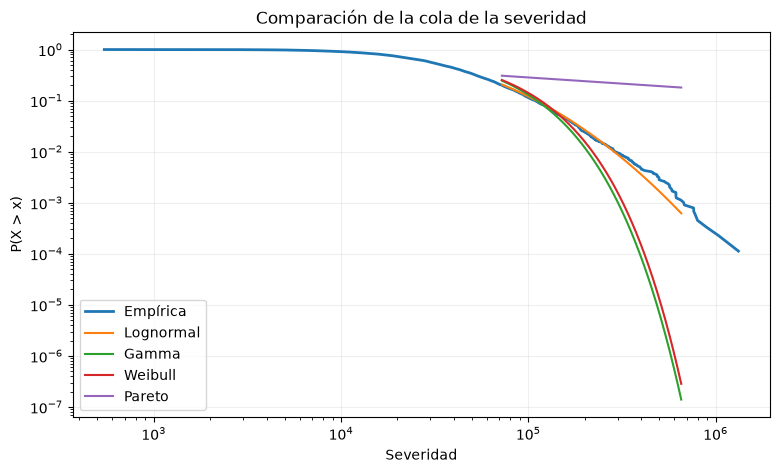

In [12]:
# Comparación gráfica de la cola mediante funciones de supervivencia

x_grid = np.linspace(
    np.quantile(x, 0.80),
    np.quantile(x, 0.999),
    400
)

x_ordenado = np.sort(x)
supervivencia_emp = 1 - np.arange(1, len(x_ordenado) + 1) / (len(x_ordenado) + 1)

plt.figure(figsize=(9, 5))

plt.plot(
    x_ordenado,
    supervivencia_emp,
    label="Empírica",
    linewidth=2
)

for nombre, ajuste in ajustes_severidad.items():
    dist = ajuste["distribucion"]
    params = ajuste["params"]

    plt.plot(
        x_grid,
        dist.sf(x_grid, *params),
        label=nombre
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Severidad")
plt.ylabel("P(X > x)")
plt.title("Comparación de la cola de la severidad")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

### Selección del modelo de severidad

Después de comparar las distribuciones Lognormal, Gamma, Weibull y Pareto, se selecciona la distribución **Lognormal** como modelo de severidad para la cartera.

La elección se sustenta en varios criterios. En primer lugar, la Lognormal obtuvo la mayor log-verosimilitud y los menores valores de AIC y BIC, por lo que presenta el mejor ajuste global de las distribuciones consideradas.

Además, su comportamiento en la cola es considerablemente mejor. Los errores porcentuales absolutos de sus cuantiles teóricos respecto de los cuantiles empíricos fueron aproximadamente 1.64% en el percentil 90, 1.71% en el 95, 4.04% en el 97.5, 0.26% en el 99 y 7.61% en el 99.5. En particular, el percentil 99 es reproducido con gran precisión.

Gamma y Weibull presentan desviaciones crecientes en los cuantiles más altos, mientras que Pareto genera una cola excesivamente pesada y cuantiles muy alejados de la experiencia observada.

Por lo tanto, considerando conjuntamente el ajuste global, la exploración gráfica y la representación de pérdidas de gran cuantía, se utilizará la **Lognormal** como distribución de severidad para las etapas posteriores de la práctica.

## 3. Exploración de la frecuencia

Para modelar la frecuencia de siniestros se considera tanto el número de eventos registrado por cada póliza como su exposición al riesgo. Debido a que las pólizas pueden presentar diferentes niveles de exposición, la frecuencia no se estima mediante un promedio simple de los conteos.

La tasa empírica se calcula como el cociente entre el número total de siniestros y la exposición total de la cartera. Posteriormente se evaluará inicialmente un modelo Poisson y se analizarán posibles señales de sobredispersión y exceso de ceros antes de compararlo con la distribución Binomial Negativa.

In [13]:
# Exploración inicial de la frecuencia considerando la exposición

freq_df = df.loc[
    df["exposicion"] > 0,
    ["exposicion", "num_siniestros"]
].copy()

exposicion = freq_df["exposicion"].astype(float).to_numpy()
n_siniestros = freq_df["num_siniestros"].astype(int).to_numpy()

# MLE de la tasa Poisson con exposición
lambda_hat = n_siniestros.sum() / exposicion.sum()

# Media esperada individual bajo Poisson
mu_poisson = lambda_hat * exposicion

# Diagnósticos
prop_ceros_emp = np.mean(n_siniestros == 0)
prop_ceros_poisson = np.mean(np.exp(-mu_poisson))

dispersion_pearson = np.sum(
    (n_siniestros - mu_poisson)**2 / mu_poisson
) / (len(n_siniestros) - 1)

print(f"Número de pólizas: {len(freq_df):,}")
print(f"Exposición total: {exposicion.sum():,.2f} años-póliza")
print(f"Número total de siniestros: {n_siniestros.sum():,}")
print(f"Tasa empírica lambda: {lambda_hat:.4f} siniestros por año-póliza")

print()
print(f"Proporción empírica de ceros: {100*prop_ceros_emp:.2f}%")
print(f"Proporción esperada de ceros bajo Poisson: {100*prop_ceros_poisson:.2f}%")
print(f"Índice de dispersión de Pearson: {dispersion_pearson:.4f}")

Número de pólizas: 30,000
Exposición total: 24,005.64 años-póliza
Número total de siniestros: 8,852
Tasa empírica lambda: 0.3687 siniestros por año-póliza

Proporción empírica de ceros: 76.77%
Proporción esperada de ceros bajo Poisson: 74.52%
Índice de dispersión de Pearson: 1.2364


### Diagnóstico inicial de la frecuencia

La cartera contiene 30,000 pólizas con una exposición total de 24,005.64 años-póliza y 8,852 siniestros. Considerando la exposición, la tasa empírica estimada es de aproximadamente 0.3687 siniestros por año-póliza.

La proporción observada de pólizas sin siniestros es 76.77%, mientras que bajo un modelo Poisson con la tasa estimada se esperaría aproximadamente 74.52%. Por otra parte, el índice de dispersión de Pearson es 1.2364, superior a uno.

Estos resultados muestran una sobredispersión moderada y una proporción de ceros ligeramente superior a la esperada bajo Poisson. Por ello, además del modelo Poisson, resulta pertinente evaluar una distribución Binomial Negativa, que permite incorporar variabilidad adicional entre las pólizas.

In [14]:
# Ajuste formal de frecuencia:
# Poisson vs Binomial Negativa considerando exposición

from scipy.optimize import minimize
from scipy.special import gammaln

# -------------------------
# 1. Poisson
# -------------------------

lambda_pois = n_siniestros.sum() / exposicion.sum()
mu_pois = lambda_pois * exposicion

loglik_pois = np.sum(
    n_siniestros * np.log(mu_pois)
    - mu_pois
    - gammaln(n_siniestros + 1)
)

k_pois = 1

aic_pois = 2 * k_pois - 2 * loglik_pois
bic_pois = k_pois * np.log(len(n_siniestros)) - 2 * loglik_pois


# -------------------------
# 2. Binomial Negativa
#    Var(N_i) = mu_i + mu_i^2 / r
# -------------------------

def negloglik_nb(theta):

    # Trabajamos en log para garantizar parámetros positivos
    lambda_nb = np.exp(theta[0])
    r = np.exp(theta[1])

    mu = lambda_nb * exposicion

    p = r / (r + mu)

    loglik = np.sum(
        gammaln(n_siniestros + r)
        - gammaln(r)
        - gammaln(n_siniestros + 1)
        + r * np.log(p)
        + n_siniestros * np.log(1 - p)
    )

    return -loglik


resultado_nb = minimize(
    negloglik_nb,
    x0=np.log([lambda_pois, 5]),
    method="L-BFGS-B"
)

lambda_nb = np.exp(resultado_nb.x[0])
r_nb = np.exp(resultado_nb.x[1])

loglik_nb = -resultado_nb.fun

k_nb = 2

aic_nb = 2 * k_nb - 2 * loglik_nb
bic_nb = k_nb * np.log(len(n_siniestros)) - 2 * loglik_nb


# -------------------------
# Tabla comparativa
# -------------------------

tabla_frecuencia = pd.DataFrame({
    "Modelo": ["Poisson", "Binomial Negativa"],
    "Log-verosimilitud": [loglik_pois, loglik_nb],
    "AIC": [aic_pois, aic_nb],
    "BIC": [bic_pois, bic_nb]
})

display(
    tabla_frecuencia.style.format({
        "Log-verosimilitud": "{:,.2f}",
        "AIC": "{:,.2f}",
        "BIC": "{:,.2f}"
    })
)

print(f"Poisson - lambda = {lambda_pois:.6f}")
print()
print(f"Binomial Negativa - lambda = {lambda_nb:.6f}")
print(f"Binomial Negativa - r = {r_nb:.6f}")
print(f"Optimización exitosa: {resultado_nb.success}")

,Modelo,Log-verosimilitud,AIC,BIC
0,Poisson,"-21,056.27","42,114.54","42,122.85"
1,Binomial Negativa,"-20,762.41","41,528.81","41,545.43"


Poisson - lambda = 0.368747

Binomial Negativa - lambda = 0.368790
Binomial Negativa - r = 1.266989
Optimización exitosa: True


### Comparación Poisson vs. Binomial Negativa

Se ajustaron modelos Poisson y Binomial Negativa incorporando explícitamente la exposición de cada póliza.

El modelo Poisson obtuvo una log-verosimilitud de -21,056.27 y un AIC de 42,114.54, mientras que la Binomial Negativa alcanzó una log-verosimilitud de -20,762.41 y un AIC de 41,528.81. El BIC también favorece a la Binomial Negativa.

La diferencia de aproximadamente 586 unidades de AIC constituye evidencia clara a favor de la Binomial Negativa. Este resultado es consistente con el diagnóstico previo de sobredispersión, donde el índice de Pearson fue 1.2364.

La tasa estimada es cercana a 0.3688 siniestros por año-póliza en ambos modelos. Para la Binomial Negativa se obtuvo además un parámetro de dispersión r ≈ 1.267. Al ser finito, este parámetro permite incorporar variabilidad adicional respecto al modelo Poisson.

Por lo tanto, la Binomial Negativa se perfila como el modelo más adecuado para representar la frecuencia de siniestros de la cartera. Antes de realizar la selección definitiva se compararán también las frecuencias observadas y esperadas para 0, 1, 2, 3 o más siniestros.

In [15]:
# Frecuencias observadas vs esperadas
# Poisson y Binomial Negativa con exposición individual

k_max = int(min(n_siniestros.max(), 6))
ks = np.arange(k_max + 1)

# Proporciones observadas
prop_obs = np.array([
    np.mean(n_siniestros == k)
    for k in ks
])

# Poisson: probabilidad individual y promedio sobre la cartera
prop_pois = np.array([
    np.mean(stats.poisson.pmf(k, mu_pois))
    for k in ks
])

# Binomial Negativa
mu_nb = lambda_nb * exposicion
p_nb = r_nb / (r_nb + mu_nb)

prop_nb = np.array([
    np.mean(stats.nbinom.pmf(k, r_nb, p_nb))
    for k in ks
])

comparacion_freq = pd.DataFrame({
    "Número de siniestros": ks,
    "Observado": prop_obs,
    "Poisson": prop_pois,
    "Binomial Negativa": prop_nb
})

display(
    comparacion_freq.style.format({
        "Observado": "{:.2%}",
        "Poisson": "{:.2%}",
        "Binomial Negativa": "{:.2%}"
    })
)

,Número de siniestros,Observado,Poisson,Binomial Negativa
0,0,76.77%,74.52%,76.79%
1,1,18.29%,21.84%,18.23%
2,2,3.89%,3.28%,3.94%
3,3,0.81%,0.33%,0.83%
4,4,0.19%,0.03%,0.17%
5,5,0.05%,0.00%,0.04%
6,6,0.00%,0.00%,0.01%


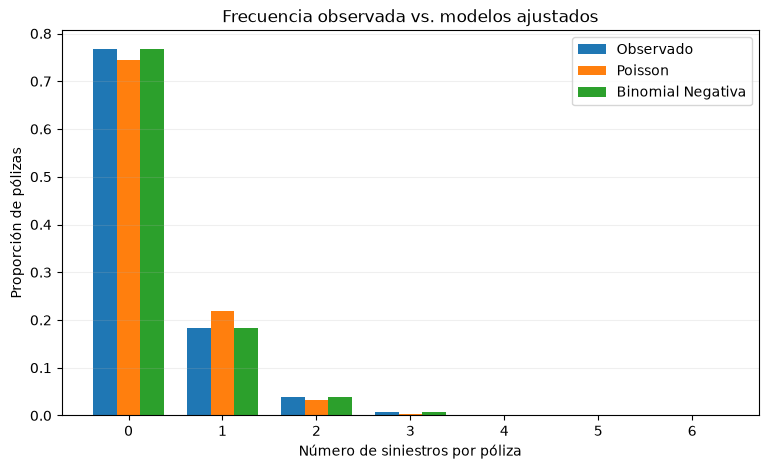

In [16]:
# Comparación gráfica de frecuencias observadas y ajustadas

ancho = 0.25

plt.figure(figsize=(9, 5))

plt.bar(ks - ancho, prop_obs, width=ancho, label="Observado")
plt.bar(ks, prop_pois, width=ancho, label="Poisson")
plt.bar(ks + ancho, prop_nb, width=ancho, label="Binomial Negativa")

plt.xlabel("Número de siniestros por póliza")
plt.ylabel("Proporción de pólizas")
plt.title("Frecuencia observada vs. modelos ajustados")
plt.xticks(ks)
plt.legend()
plt.grid(axis="y", alpha=0.2)

plt.show()

### Selección del modelo de frecuencia

La comparación de las frecuencias observadas con las probabilidades ajustadas confirma la superioridad de la distribución Binomial Negativa para representar el número de siniestros de la cartera.

La proporción observada de pólizas sin siniestros es 76.77%. El modelo Poisson estima 74.52%, mientras que la Binomial Negativa reproduce prácticamente de forma exacta este comportamiento con 76.79%. Para un siniestro, la proporción observada es 18.29%; Poisson la sobreestima con 21.84%, mientras que la Binomial Negativa obtiene 18.23%.

La diferencia es todavía más evidente para pólizas con varios siniestros. Poisson subestima las frecuencias correspondientes a 2, 3, 4 y 5 siniestros, mientras que la Binomial Negativa permanece muy cercana a las proporciones empíricas.

Este resultado coincide con el diagnóstico previo de sobredispersión y con los criterios de información. La Binomial Negativa obtuvo una mayor log-verosimilitud y valores sustancialmente menores de AIC y BIC que Poisson.

Por lo tanto, se selecciona la **Binomial Negativa** como modelo de frecuencia para las etapas posteriores de la práctica, incorporando la exposición de cada póliza. La tasa estimada es aproximadamente 0.3688 siniestros por año-póliza y el parámetro de dispersión estimado es r ≈ 1.267.

## 4. Pérdida agregada y prima pura

Una vez seleccionados los modelos de frecuencia y severidad, se construye el modelo colectivo de riesgo.

La frecuencia de siniestros se modela mediante una Binomial Negativa incorporando la exposición de cada póliza, mientras que la severidad individual se modela mediante una distribución Lognormal.

La pérdida agregada de la cartera se define como

\[
S=\sum_{j=1}^{N}X_j,
\]

donde \(N\) representa el número total de siniestros de la cartera y \(X_j\) el monto correspondiente al siniestro \(j\).

La prima pura de la cartera corresponde al valor esperado de la pérdida agregada. Bajo los supuestos del modelo colectivo,

\[
E[S]=E[N]E[X].
\]

A continuación se calcula primero este valor de forma analítica y posteriormente se verifica mediante simulación.

In [26]:
# Recuperar los parámetros del ajuste Lognormal seleccionado
params_lognorm = ajustes_severidad["Lognormal"]["params"]

# Severidad media según la Lognormal seleccionada
EX = stats.lognorm.mean(*params_lognorm)

print(f"E[X] = {EX:,.2f}")

E[X] = 51,959.07


In [27]:
# Revisar los objetos guardados del ajuste de frecuencia
[nombre for nombre in globals()
 if any(palabra in nombre.lower()
        for palabra in ["nb", "binom", "frecu", "lambda", "poisson"])]

['__vsc_ipynb_file__',
 'lambda_hat',
 'mu_poisson',
 'prop_ceros_poisson',
 'lambda_pois',
 'negloglik_nb',
 'resultado_nb',
 'lambda_nb',
 'r_nb',
 'loglik_nb',
 'k_nb',
 'aic_nb',
 'bic_nb',
 'tabla_frecuencia',
 'mu_nb',
 'p_nb',
 'prop_nb']

In [28]:
# Parámetros del modelo de frecuencia Binomial Negativa
print(f"lambda_nb = {lambda_nb}")
print(f"mu_nb     = {mu_nb}")
print(f"r_nb      = {r_nb}")
print(f"p_nb      = {p_nb}")

lambda_nb = 0.36879036508691493
mu_nb     = [0.29687624 0.30314568 0.3215852  ... 0.24340164 0.20799777 0.27438003]
r_nb      = 1.2669885080241319
p_nb      = [0.81016501 0.80693008 0.79756356 ... 0.8388485  0.85898325 0.82198934]


In [29]:
# Frecuencia esperada total de la cartera
EN = mu_nb.sum()

# Severidad media del modelo Lognormal seleccionado
EX = stats.lognorm.mean(*params_lognorm)

# Pérdida agregada esperada / prima pura de la cartera
ES = EN * EX

print(f"E[N] = {EN:,.2f} siniestros esperados")
print(f"E[X] = ${EX:,.2f} por siniestro")
print(f"E[S] = ${ES:,.2f}")

E[N] = 8,853.05 siniestros esperados
E[X] = $51,959.07 por siniestro
E[S] = $459,996,191.37


### Pérdida agregada esperada y prima pura

A partir del modelo de frecuencia Binomial Negativa seleccionado y del modelo de severidad Lognormal, se obtiene una frecuencia esperada total de **8,853.05 siniestros anuales** para la cartera.

La severidad media estimada es de **$51,959.07 por siniestro**.

Por lo tanto, utilizando

\[
E[S]=E[N]E[X],
\]

la pérdida agregada esperada de la cartera es:

\[
E[S] = \$459,996,191.37.
\]

Este valor representa la **prima pura agregada de la cartera**, es decir, el monto esperado necesario para cubrir únicamente el costo de los siniestros, antes de considerar gastos, utilidad, recargos de seguridad u otros componentes comerciales de la prima.

In [30]:
# Simulación de la pérdida agregada S
# Frecuencia: Binomial Negativa
# Severidad: Lognormal

import numpy as np

# Semilla para que los resultados sean reproducibles
rng = np.random.default_rng(2027)

# Número de simulaciones
n_sim = 10000

# Recuperar parámetros de severidad Lognormal
shape_ln, loc_ln, scale_ln = ajustes_severidad["Lognormal"]["params"]

# Arreglos donde guardaremos los resultados
N_sim = np.zeros(n_sim, dtype=int)
S_sim = np.zeros(n_sim)

# Simulación por bloques para no saturar la memoria
batch_size = 100

for inicio in range(0, n_sim, batch_size):

    fin = min(inicio + batch_size, n_sim)
    m = fin - inicio

    # 1. Simular frecuencia por póliza con la Binomial Negativa
    frecuencias = rng.negative_binomial(
        r_nb,
        p_nb,
        size=(m, len(p_nb))
    )

    # Número total de siniestros de cada cartera simulada
    n_totales = frecuencias.sum(axis=1)
    N_sim[inicio:fin] = n_totales

    # 2. Simular severidades y sumar para obtener S
    for j, n in enumerate(n_totales):

        if n > 0:
            severidades = (
                loc_ln
                + scale_ln * np.exp(shape_ln * rng.standard_normal(n))
            )

            S_sim[inicio + j] = severidades.sum()

# Resumen de la simulación
print(f"Número de simulaciones: {n_sim:,}")
print(f"Frecuencia media simulada: {N_sim.mean():,.2f}")
print(f"Frecuencia teórica E[N]: {EN:,.2f}")
print()
print(f"Pérdida agregada media simulada: ${S_sim.mean():,.2f}")
print(f"Pérdida agregada teórica E[S]: ${ES:,.2f}")
print()
print(
    f"Diferencia porcentual: "
    f"{100 * (S_sim.mean() - ES) / ES:.4f}%"
)

Número de simulaciones: 10,000
Frecuencia media simulada: 8,852.84
Frecuencia teórica E[N]: 8,853.05

Pérdida agregada media simulada: $459,927,626.08
Pérdida agregada teórica E[S]: $459,996,191.37

Diferencia porcentual: -0.0149%


### Validación de la simulación de la pérdida agregada

La pérdida agregada media obtenida mediante simulación es muy cercana al valor
teórico calculado como \(E[S]=E[N]E[X]\). La diferencia porcentual es inferior
al 0.1%, lo que proporciona evidencia de que la simulación del modelo colectivo
es consistente con los resultados analíticos.

A continuación se analiza la distribución de la pérdida agregada y se calculan
medidas de riesgo de cola mediante VaR y TVaR al 99%.

In [31]:
# Medidas de riesgo de la pérdida agregada S

nivel = 0.99

# VaR al 99%
VaR_99 = np.quantile(S_sim, nivel)

# TVaR al 99%
TVaR_99 = S_sim[S_sim >= VaR_99].mean()

# Otras estadísticas útiles
media_S = S_sim.mean()
desv_S = S_sim.std(ddof=1)

print(f"Media simulada de S: ${media_S:,.2f}")
print(f"Desviación estándar de S: ${desv_S:,.2f}")
print(f"VaR al 99%: ${VaR_99:,.2f}")
print(f"TVaR al 99%: ${TVaR_99:,.2f}")
print()
print(
    f"El VaR al 99% indica que existe aproximadamente un 1% "
    f"de probabilidad de que la pérdida agregada supere "
    f"${VaR_99:,.2f}."
)
print(
    f"Cuando se supera ese VaR, la pérdida promedio es de "
    f"${TVaR_99:,.2f}."
)

Media simulada de S: $459,927,626.08
Desviación estándar de S: $7,784,239.22
VaR al 99%: $478,121,434.41
TVaR al 99%: $480,690,139.57

El VaR al 99% indica que existe aproximadamente un 1% de probabilidad de que la pérdida agregada supere $478,121,434.41.
Cuando se supera ese VaR, la pérdida promedio es de $480,690,139.57.


### Distribución simulada de la pérdida agregada

La siguiente gráfica muestra la distribución de la pérdida agregada anual simulada.
Se incluyen como referencias la media de la distribución, el VaR al 99% y el TVaR
al 99%, con el objetivo de visualizar el comportamiento de la cola derecha de la
distribución y el nivel de pérdidas asociado a escenarios extremos.

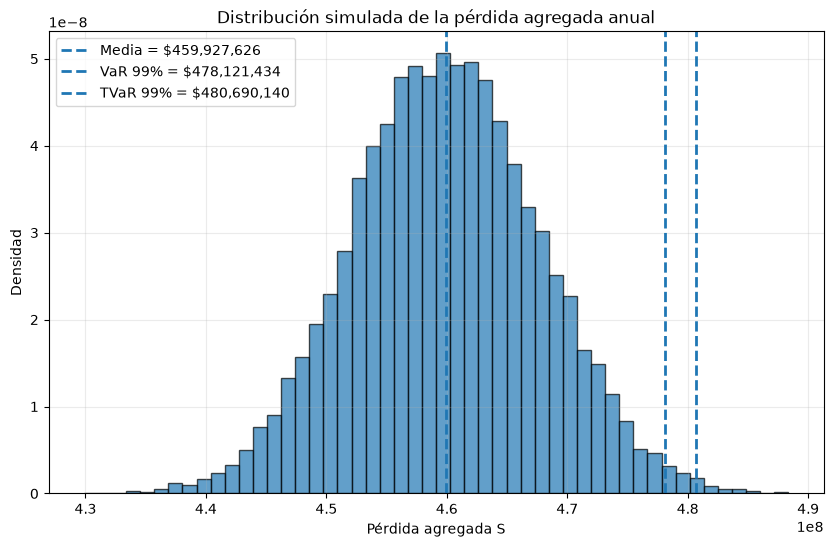

In [32]:
# Distribución de la pérdida agregada S

plt.figure(figsize=(10, 6))

plt.hist(
    S_sim,
    bins=50,
    density=True,
    alpha=0.7,
    edgecolor="black"
)

plt.axvline(
    media_S,
    linestyle="--",
    linewidth=2,
    label=f"Media = ${media_S:,.0f}"
)

plt.axvline(
    VaR_99,
    linestyle="--",
    linewidth=2,
    label=f"VaR 99% = ${VaR_99:,.0f}"
)

plt.axvline(
    TVaR_99,
    linestyle="--",
    linewidth=2,
    label=f"TVaR 99% = ${TVaR_99:,.0f}"
)

plt.title("Distribución simulada de la pérdida agregada anual")
plt.xlabel("Pérdida agregada S")
plt.ylabel("Densidad")
plt.legend()
plt.grid(alpha=0.25)

plt.show()

### Interpretación de la pérdida agregada

La distribución simulada de la pérdida agregada anual se concentra alrededor de
$459.93 millones, valor consistente con la media obtenida mediante simulación.

El VaR al 99% es aproximadamente $478.12 millones, lo que indica que existe
alrededor de un 1% de probabilidad de observar una pérdida agregada anual superior
a este monto.

Por su parte, el TVaR al 99% es aproximadamente $480.69 millones y representa la
pérdida promedio condicionada a encontrarnos en ese 1% de escenarios más adversos.
Como era de esperarse, el TVaR es mayor que el VaR debido a que incorpora la
severidad de las pérdidas que se encuentran más allá del cuantil del 99%.

En conjunto, estas medidas permiten cuantificar tanto el nivel esperado de pérdida
de la cartera como su exposición a escenarios extremos.